In [104]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [105]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
    return hasil

def erosi(citra, mask):
    pad_t, pad_l = mask.shape[0] // 2, mask.shape[1] // 2
    citra_pad = np.pad(citra, ((pad_t, pad_t), (pad_l, pad_l)),
                       mode='constant', constant_values=255)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for r in range(pad_t, citra_pad.shape[0] - pad_t):
        for c in range(pad_l, citra_pad.shape[1] - pad_l):
            blok = citra_pad[r-pad_t:r+pad_t+1, c-pad_l:c+pad_l+1]
            if np.all(blok[mask == 1] == 255):
                hasil[r-pad_t, c-pad_l] = 255
    return hasil

def gradient_morph(img, kernel):
    img_uint8 = img.astype(np.uint8)
    _, img_binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hasil_dilasi = dilasi(img_binary, kernel).astype(np.float32)
    hasil_erosi  = erosi(img_binary, kernel).astype(np.float32)
    gradien = hasil_dilasi - hasil_erosi
    return np.clip(gradien, 0, 255).astype(np.uint8)
    
kernel_morph = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
 
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def gabung_tepi(*edges):
    gabungan = np.zeros_like(edges[0], dtype=np.float32)
    for e in edges:
        gabungan += e.astype(np.float32)
    gabungan = gabungan * 255.0 / np.max(gabungan)
    return np.clip(gabungan, 0, 255).astype(np.uint8)

sobelx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]],dtype=np.float32)
sobely = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=np.float32)

prewittx = np.array([[-1, 0, 1],
                      [-1, 0, 1], 
                      [-1, 0, 1]], dtype=np.float32)
prewitty = np.array([[1, 1, 1], 
                      [0, 0, 0], 
                      [-1, -1, -1]], dtype=np.float32)

robertsx = np.array([[1, 0], 
                     [0, -1]], dtype=np.float32)
robertsy = np.array([[0, 1], 
                     [-1, 0]], dtype=np.float32)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

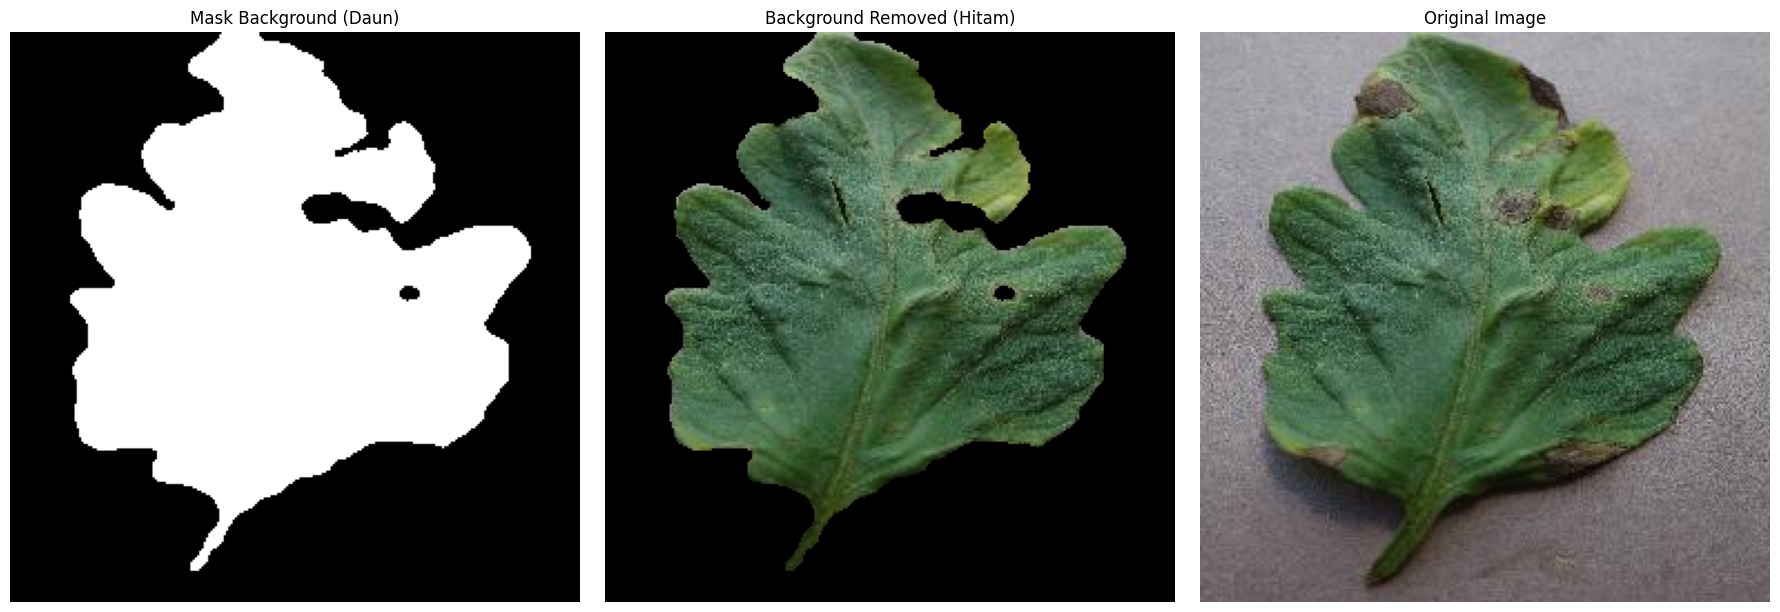

In [106]:
daun_bgr = cv2.imread('archive/tomato/early.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)
daun_gray = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2GRAY)

daun_smoothed = filter(daun_gray, 3, 'mean')

tinggi, lebar = daun_rgb.shape[:2]
mask_fg = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        
        if (g > r + 10) and (g > b + 10):
            mask_fg[i, j] = 255
        else:
            mask_fg[i, j] = 0

mask_fg_clean = filter(mask_fg, 5, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_clean[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.imshow(mask_fg_clean, cmap='gray')
plt.title('Mask Background (Daun)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(daun_removed)
plt.title('Background Removed (Hitam)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(daun_rgb)
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

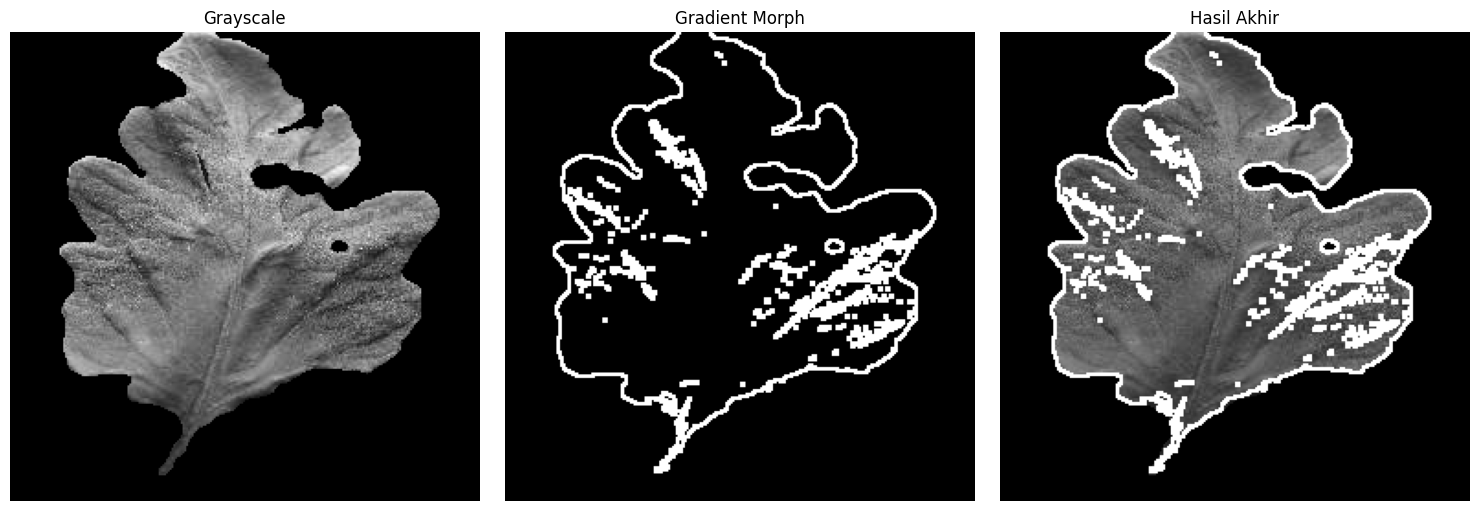

In [107]:
daun_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)
grad = gradient_morph(daun_gray, kernel_morph)
hasil_akhir = np.clip(daun_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()

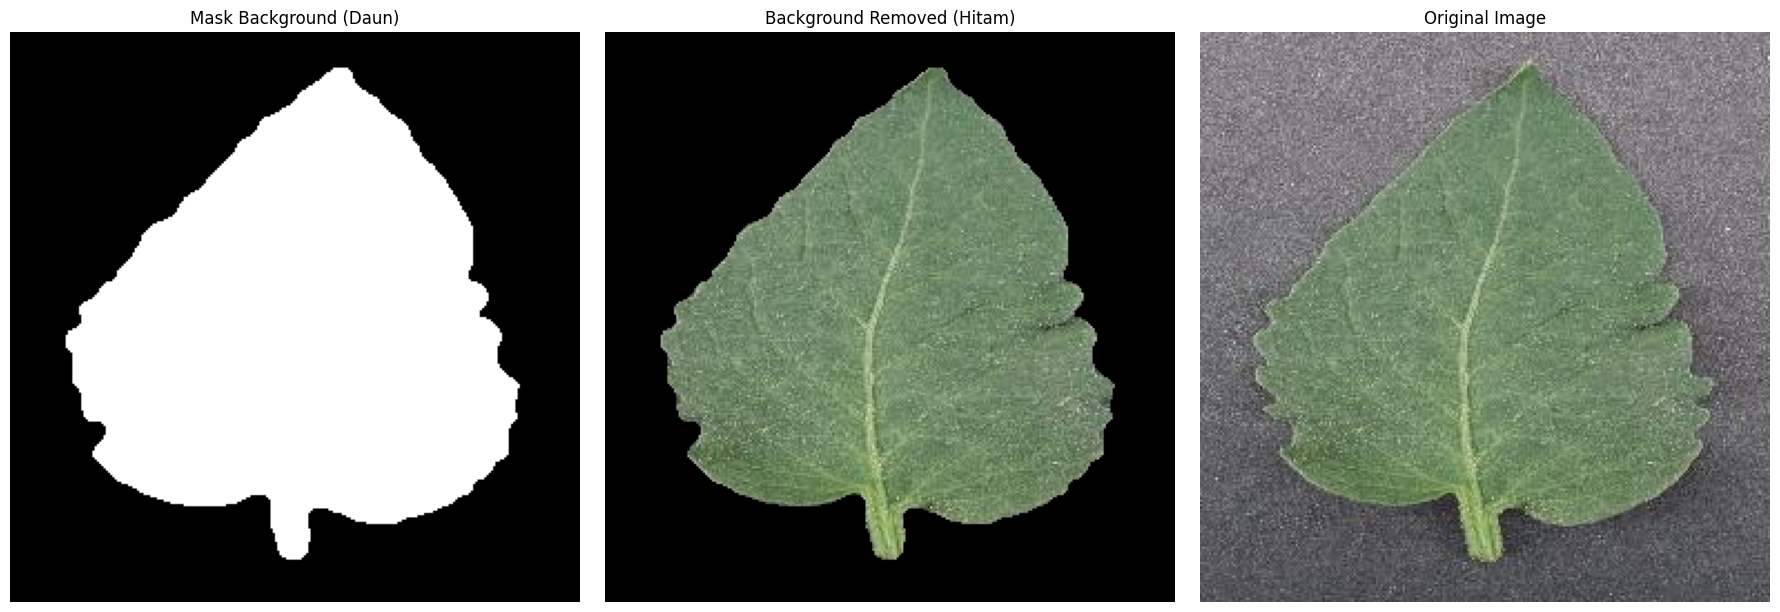

In [108]:
daun_bgr = cv2.imread('archive/tomato/healty.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)
daun_gray = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2GRAY)

daun_smoothed = filter(daun_gray, 3, 'mean')

tinggi, lebar = daun_rgb.shape[:2]
mask_fg = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        
        if (g > r + 10) and (g > b + 10):
            mask_fg[i, j] = 255
        else:
            mask_fg[i, j] = 0

mask_fg_clean = filter(mask_fg, 5, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_clean[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.imshow(mask_fg_clean, cmap='gray')
plt.title('Mask Background (Daun)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(daun_removed)
plt.title('Background Removed (Hitam)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(daun_rgb)
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

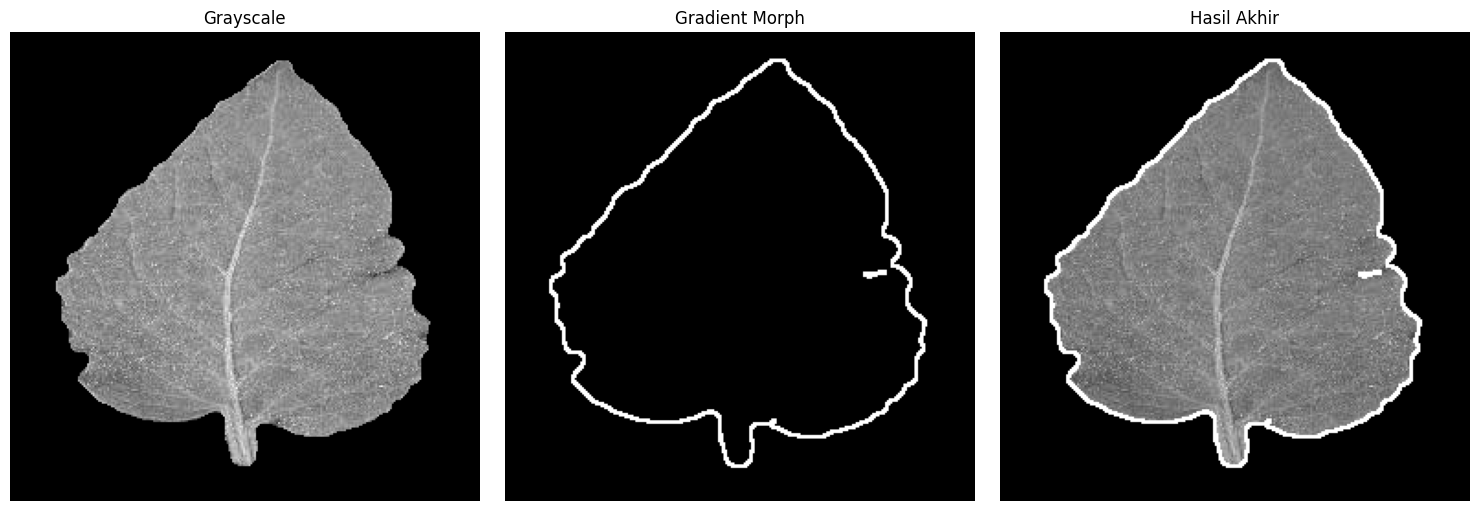

In [109]:
daun_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)
grad = gradient_morph(daun_gray, kernel_morph)
hasil_akhir = np.clip(daun_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()

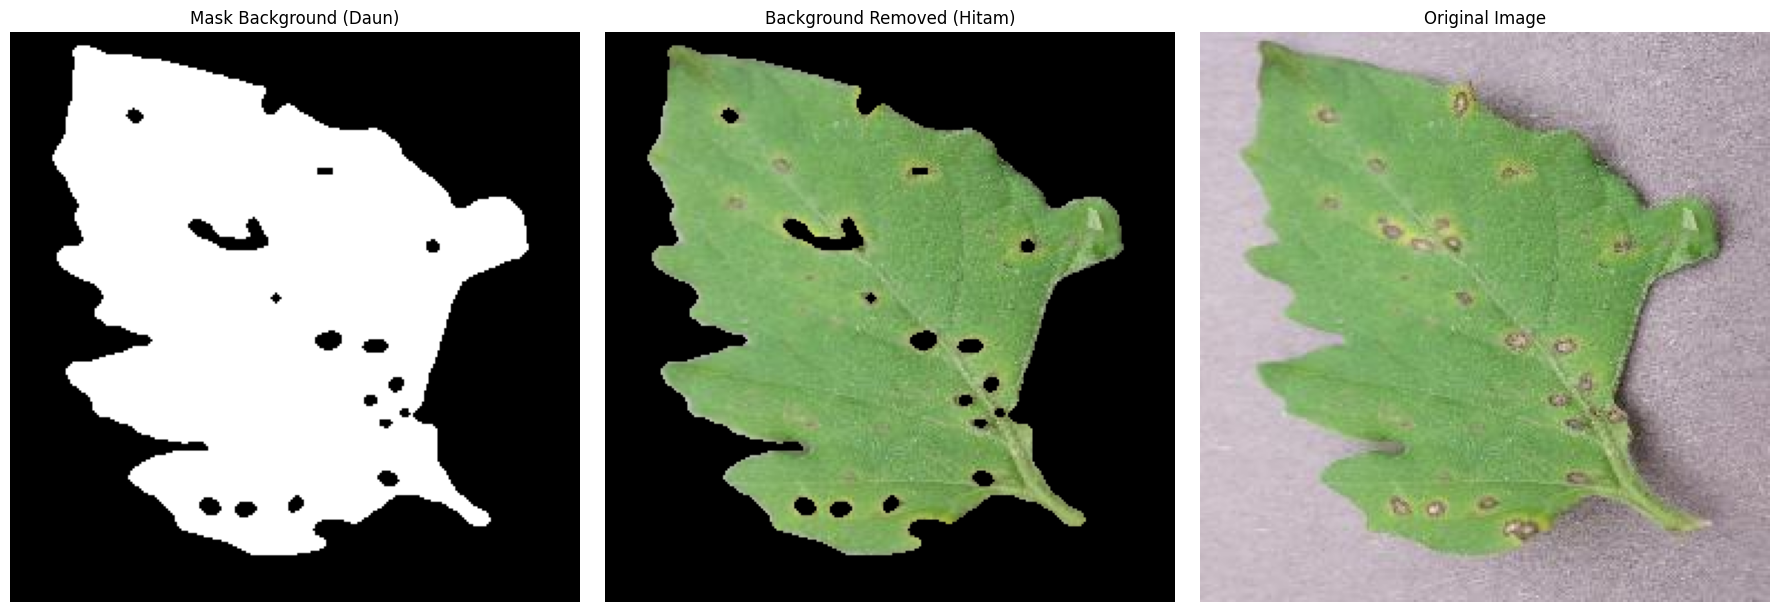

In [110]:
daun_bgr = cv2.imread('archive/tomato/septoria.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)
daun_gray = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2GRAY)

daun_smoothed = filter(daun_gray, 3, 'mean')

tinggi, lebar = daun_rgb.shape[:2]
mask_fg = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        
        if (g > r + 10) and (g > b + 10):
            mask_fg[i, j] = 255
        else:
            mask_fg[i, j] = 0

mask_fg_clean = filter(mask_fg, 5, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_clean[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.imshow(mask_fg_clean, cmap='gray')
plt.title('Mask Background (Daun)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(daun_removed)
plt.title('Background Removed (Hitam)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(daun_rgb)
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

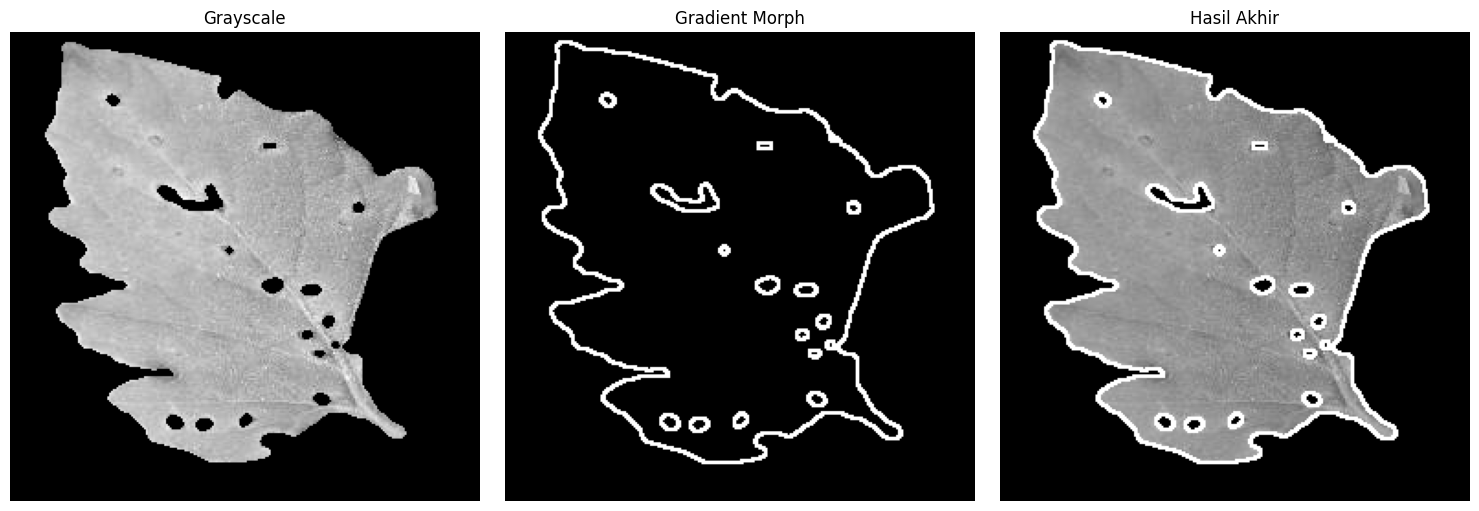

In [111]:
daun_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)
grad = gradient_morph(daun_gray, kernel_morph)
hasil_akhir = np.clip(daun_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()